<a href="https://colab.research.google.com/github/satyamkarn100-ctrl/Credit-Card-Fraud-Detection-ML/blob/main/URL_Phishing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
!pip install tldextract
import tldextract


In [20]:
from google.colab import files
uploaded = files.upload()

Saving malicious_phish.csv to malicious_phish.csv


In [21]:
malicious_df = pd.read_csv(r'malicious_phish.csv')
historic_df = malicious_df.copy()
malicious_df.head(10)

,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement
5,http://buzzfil.net/m/show-art/ils-etaient-loin...,benign
6,espn.go.com/nba/player/_/id/3457/brandon-rush,benign
7,yourbittorrent.com/?q=anthony-hamilton-soulife,benign
8,http://www.pashminaonline.com/pure-pashminas,defacement
9,allmusic.com/album/crazy-from-the-heat-r16990,benign


,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement
5,http://buzzfil.net/m/show-art/ils-etaient-loin...,benign
6,espn.go.com/nba/player/_/id/3457/brandon-rush,benign
7,yourbittorrent.com/?q=anthony-hamilton-soulife,benign
8,http://www.pashminaonline.com/pure-pashminas,defacement
9,allmusic.com/album/crazy-from-the-heat-r16990,benign


In [22]:
print(f"Shape: {malicious_df.shape}")
print("\nLabel distribution:")
print(malicious_df['type'].value_counts())
print('\nMissing Values:')
print(malicious_df.isnull().sum())
print(f"\nDuplicates: {malicious_df.duplicated().sum()}")

Shape: (651191, 2)

Label distribution:
type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64

Missing Values:
url     0
type    0
dtype: int64

Duplicates: 10066
Shape: (651191, 2)

Label distribution:
type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64

Missing Values:
url     0
type    0
dtype: int64

Duplicates: 10066


In [23]:
malicious_df.drop_duplicates(inplace=True)

In [24]:
malicious_df.tail()

,url,type
651186,xbox360.ign.com/objects/850/850402.html,phishing
651187,games.teamxbox.com/xbox-360/1860/Dead-Space/,phishing
651188,www.gamespot.com/xbox360/action/deadspace/,phishing
651189,en.wikipedia.org/wiki/Dead_Space_(video_game),phishing
651190,www.angelfire.com/goth/devilmaycrytonite/,phishing


,url,type
651186,xbox360.ign.com/objects/850/850402.html,phishing
651187,games.teamxbox.com/xbox-360/1860/Dead-Space/,phishing
651188,www.gamespot.com/xbox360/action/deadspace/,phishing
651189,en.wikipedia.org/wiki/Dead_Space_(video_game),phishing
651190,www.angelfire.com/goth/devilmaycrytonite/,phishing


# Label Encoding


In [25]:
label_map = {
    'benign': 0,
    'phishing':1,
    'defacement':2,
    'malware':3,

}
malicious_df['label'] = malicious_df['type'].map(label_map)

print(malicious_df[['type','label']].drop_duplicates().sort_values('label'))
print(f"\nNull Labels:{malicious_df['label'].isnull().sum()}")


          type  label
1       benign      0
0     phishing      1
3   defacement      2
38     malware      3

Null Labels:0
          type  label
1       benign      0
0     phishing      1
3   defacement      2
38     malware      3

Null Labels:0


# Feature Engineering

In [26]:
malicious_df['url_length'] = malicious_df['url'].str.len()
malicious_df['hyphen_count'] = malicious_df['url'].str.count('-')
malicious_df['dot_count'] = malicious_df['url'].str.count(r'\.')
malicious_df['slash_count'] =malicious_df["url"].str.count('/')
malicious_df['special_char_count'] = malicious_df['url'].str.count(r'[@?=&%]')

malicious_df['has_https'] = malicious_df['url'].str.startswith('https')
malicious_df['has_at'] = malicious_df['url'].str.contains('@',regex=False)
malicious_df['has_double_slash'] = malicious_df['url'].str.contains('//',regex=False)

domain_only = malicious_df['url'].str.replace(r'https?://','',regex=True).str.split("/").str[0]
malicious_df['subdomain_count'] = domain_only.str.count(r'\.')

malicious_df['query_length'] = malicious_df['url'].str.split('?', n=1).str[1].str.len().fillna(0)
malicious_df['path_length'] = malicious_df['url'].str.extract(r'^https?://[^/]+(/[^?]*)')[0].str.len().fillna(0)

keyword_pattern = 'login|verify|secure|bank|paypal|update|account|signin'
malicious_df['phishing_keyword'] = malicious_df['url'].str.contains(keyword_pattern, case=False, regex=True)

ip_pattern = r"\b(?:\d{1,3}\.){3}\d{1,3}\b"
malicious_df['has_ip'] = malicious_df['url'].str.contains(ip_pattern, regex=True).fillna(False).astype(int)

In [27]:
malicious_df.head()

,url,type,label,url_length,hyphen_count,dot_count,slash_count,special_char_count,has_https,has_at,has_double_slash,subdomain_count,query_length,path_length,phishing_keyword,has_ip
0,br-icloud.com.br,phishing,1,16,1,2,0,0,False,False,False,2,0.0,0.0,False,0
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,0,2,2,0,False,False,False,1,0.0,0.0,False,0
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,0,2,3,0,False,False,False,1,0.0,0.0,False,0
3,http://www.garage-pirenne.be/index.php?option=...,defacement,2,88,1,3,3,8,False,False,True,2,49.0,10.0,False,0
4,http://adventure-nicaragua.net/index.php?optio...,defacement,2,235,1,2,3,6,False,False,True,1,194.0,10.0,False,0


,url,type,label,url_length,hyphen_count,dot_count,slash_count,special_char_count,has_https,has_at,has_double_slash,subdomain_count,query_length,path_length,phishing_keyword,has_ip
0,br-icloud.com.br,phishing,1,16,1,2,0,0,False,False,False,2,0.0,0.0,False,0
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,0,2,2,0,False,False,False,1,0.0,0.0,False,0
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,0,2,3,0,False,False,False,1,0.0,0.0,False,0
3,http://www.garage-pirenne.be/index.php?option=...,defacement,2,88,1,3,3,8,False,False,True,2,49.0,10.0,False,0
4,http://adventure-nicaragua.net/index.php?optio...,defacement,2,235,1,2,3,6,False,False,True,1,194.0,10.0,False,0


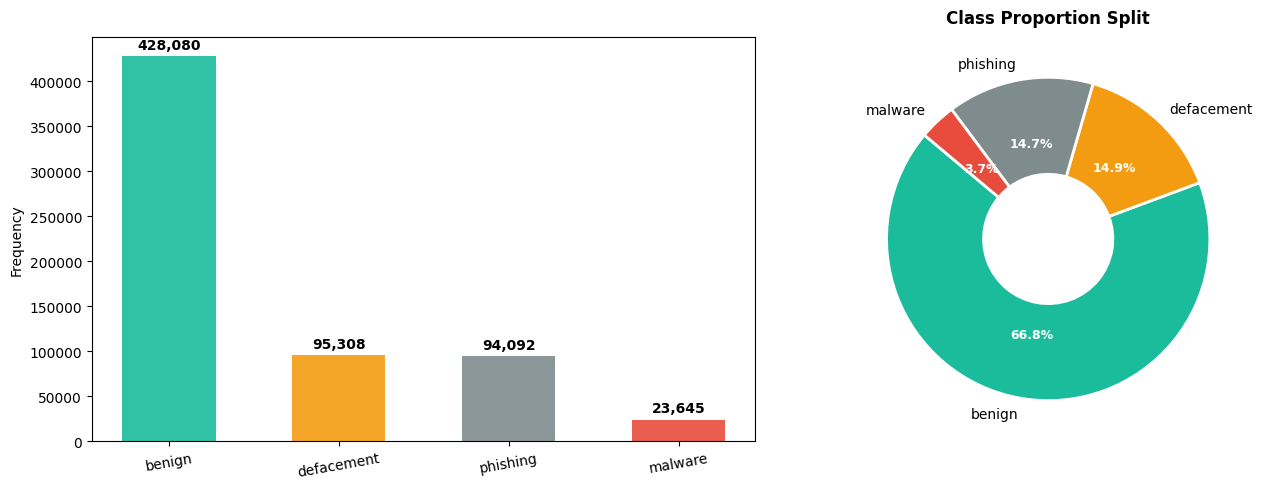

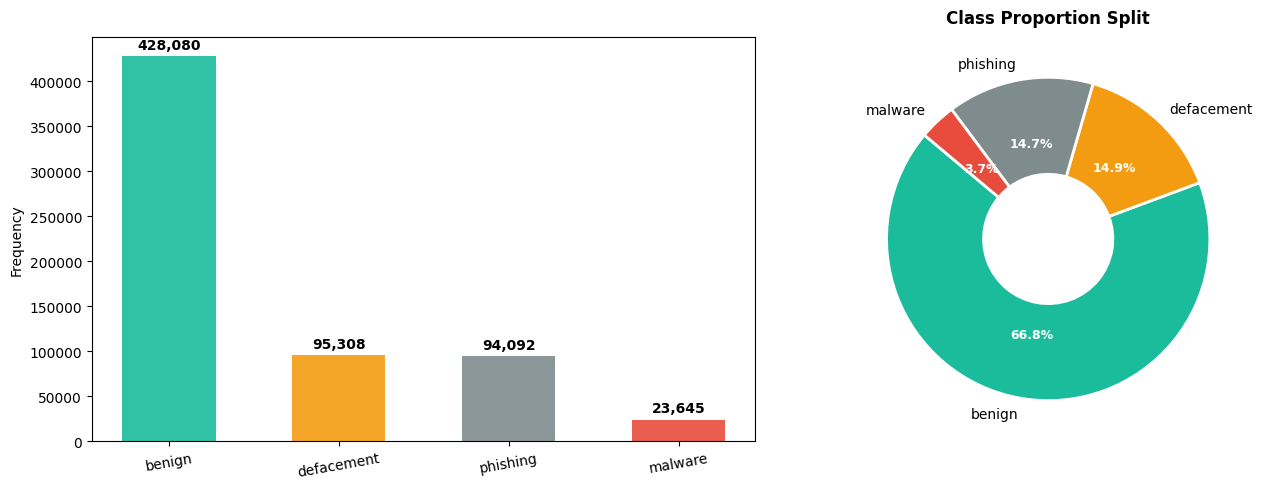

In [28]:
fig,axes = plt.subplots(1,2,figsize=(14,5))
counts = malicious_df['type'].value_counts()
# plt.style.use('dark_background')

bar_colors = ['#1abc9c', '#f39c12', '#7f8c8d', '#e74c3c']
bars = axes[0].bar(counts.index,counts.values,color=bar_colors,edgecolor="none",width=0.55,alpha=0.9)
axes[0].set_ylabel('Frequency',fontsize=10)
axes[0].tick_params(axis='x', rotation=10)

for i in bars:
  yval = i.get_height()
  axes[0].text(i.get_x()+ i.get_width()/2.0,yval+5000,f"{yval:,}",
               ha='center',va = 'bottom',fontsize=10,fontweight='bold')


wadges,texts,autotexts = axes[1].pie(counts.values,labels=counts.index
                                     ,autopct="%1.1f%%",startangle=140,colors = bar_colors,wedgeprops=dict(width=0.6,edgecolor='white',linewidth=2)
                                     )


plt.setp(autotexts, size=9, weight="bold", color="white")
plt.setp(texts, size=10)
axes[1].set_title('Class Proportion Split', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

['77.228.191.183:7674/zeujuus/a/modules/config.bin', 'http://159.8.95.53/Financeiro/2Via(Boleto-Cobranca).zip', '77.228.191.183:7890/zejius/5GPR0iy9/bot.exe', '210.37.11.238/jm32/includes/site/gate.php', 'http://54.167.101.139/gg2.dat?a=5B0B283F-8345-2E4D-66FB-B4889E225B54&amp;b=13&amp;a=015&amp;b=15&amp;c=015_20150419_0731', 'http://61.132.88.42/zxyey/uploadfile/jpg/2010-10/20101015134043714.jpg', '77.228.191.183:7890/zejius/2HZG41Zw/fJsnC6G4sFg2wsyn4shb.bin', '210.37.11.238/jm32/includes/site/bot.exe', '77.228.191.183:7890/zejius/5GPR0iy9/6Vtmo6w4yQ5tnsBHms64.php', '77.228.191.183:7890/zejius/2HZG41Zw/6Vtmo6w4yQ5tnsBHms64.php', '77.228.191.183:7890/zejius/2HZG41Zw/bot.exe', '77.228.191.183:7674/zeujuus/a/gate.php', '77.228.191.183:7674/zeujuus/a/modules/bot.exe', '77.228.191.183:7890/zejius/5GPR0iy9/fJsnC6G4sFg2wsyn4shb.bin', '210.37.11.238/jm32/includes/site/config.bin', 'http://95.8.55.230:23693/.i', 'http://61.83.184.120:56504/.i', 'http://159.65.108.249/mips', 'http://159.65.108.

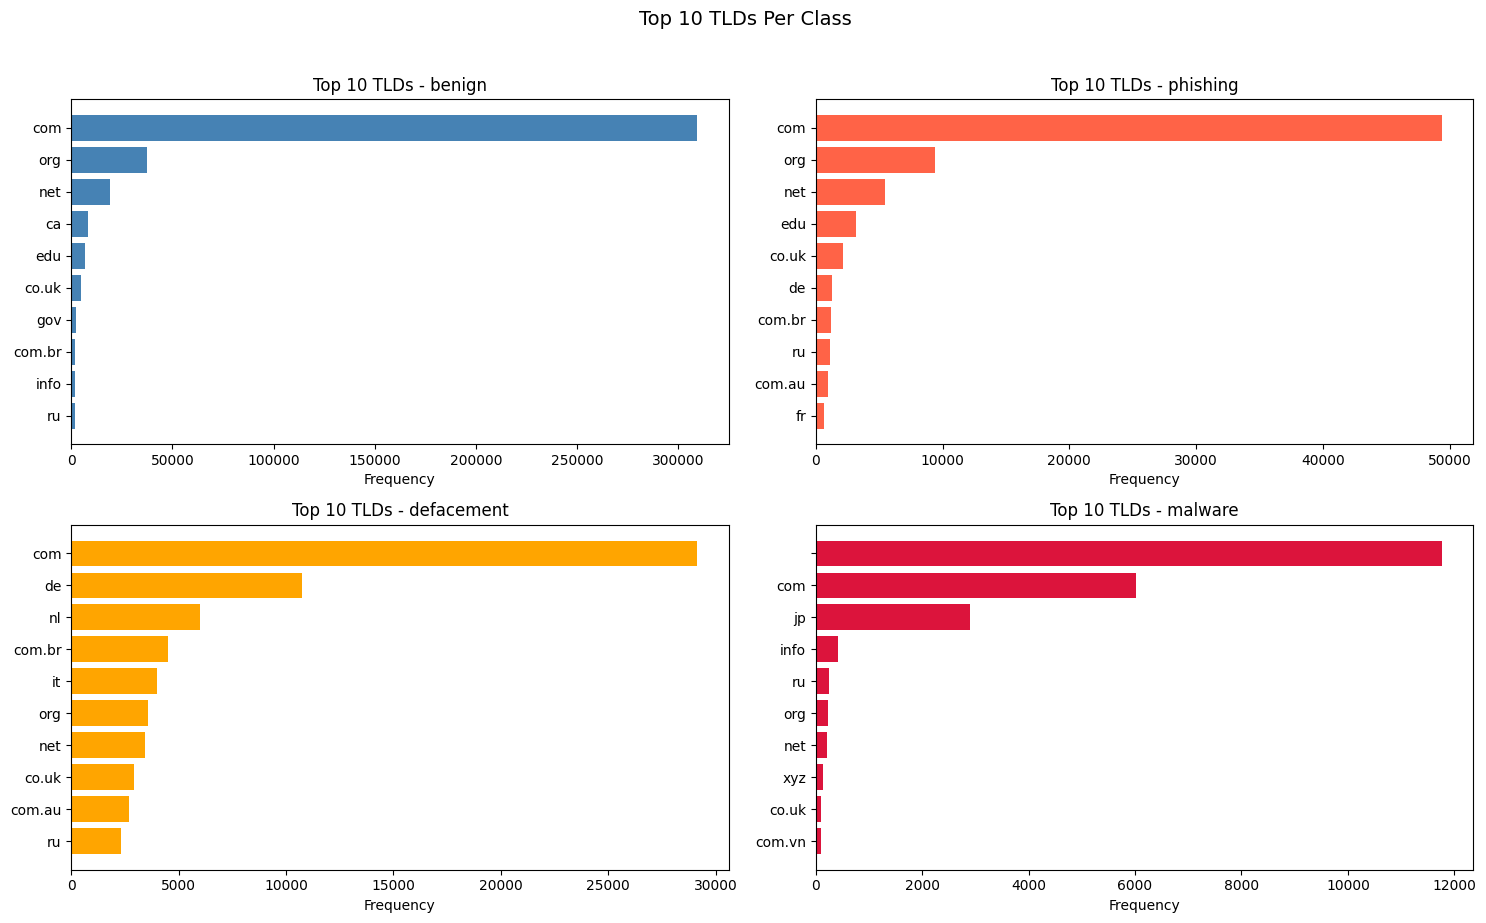

['77.228.191.183:7674/zeujuus/a/modules/config.bin', 'http://159.8.95.53/Financeiro/2Via(Boleto-Cobranca).zip', '77.228.191.183:7890/zejius/5GPR0iy9/bot.exe', '210.37.11.238/jm32/includes/site/gate.php', 'http://54.167.101.139/gg2.dat?a=5B0B283F-8345-2E4D-66FB-B4889E225B54&amp;b=13&amp;a=015&amp;b=15&amp;c=015_20150419_0731', 'http://61.132.88.42/zxyey/uploadfile/jpg/2010-10/20101015134043714.jpg', '77.228.191.183:7890/zejius/2HZG41Zw/fJsnC6G4sFg2wsyn4shb.bin', '210.37.11.238/jm32/includes/site/bot.exe', '77.228.191.183:7890/zejius/5GPR0iy9/6Vtmo6w4yQ5tnsBHms64.php', '77.228.191.183:7890/zejius/2HZG41Zw/6Vtmo6w4yQ5tnsBHms64.php', '77.228.191.183:7890/zejius/2HZG41Zw/bot.exe', '77.228.191.183:7674/zeujuus/a/gate.php', '77.228.191.183:7674/zeujuus/a/modules/bot.exe', '77.228.191.183:7890/zejius/5GPR0iy9/fJsnC6G4sFg2wsyn4shb.bin', '210.37.11.238/jm32/includes/site/config.bin', 'http://95.8.55.230:23693/.i', 'http://61.83.184.120:56504/.i', 'http://159.65.108.249/mips', 'http://159.65.108.

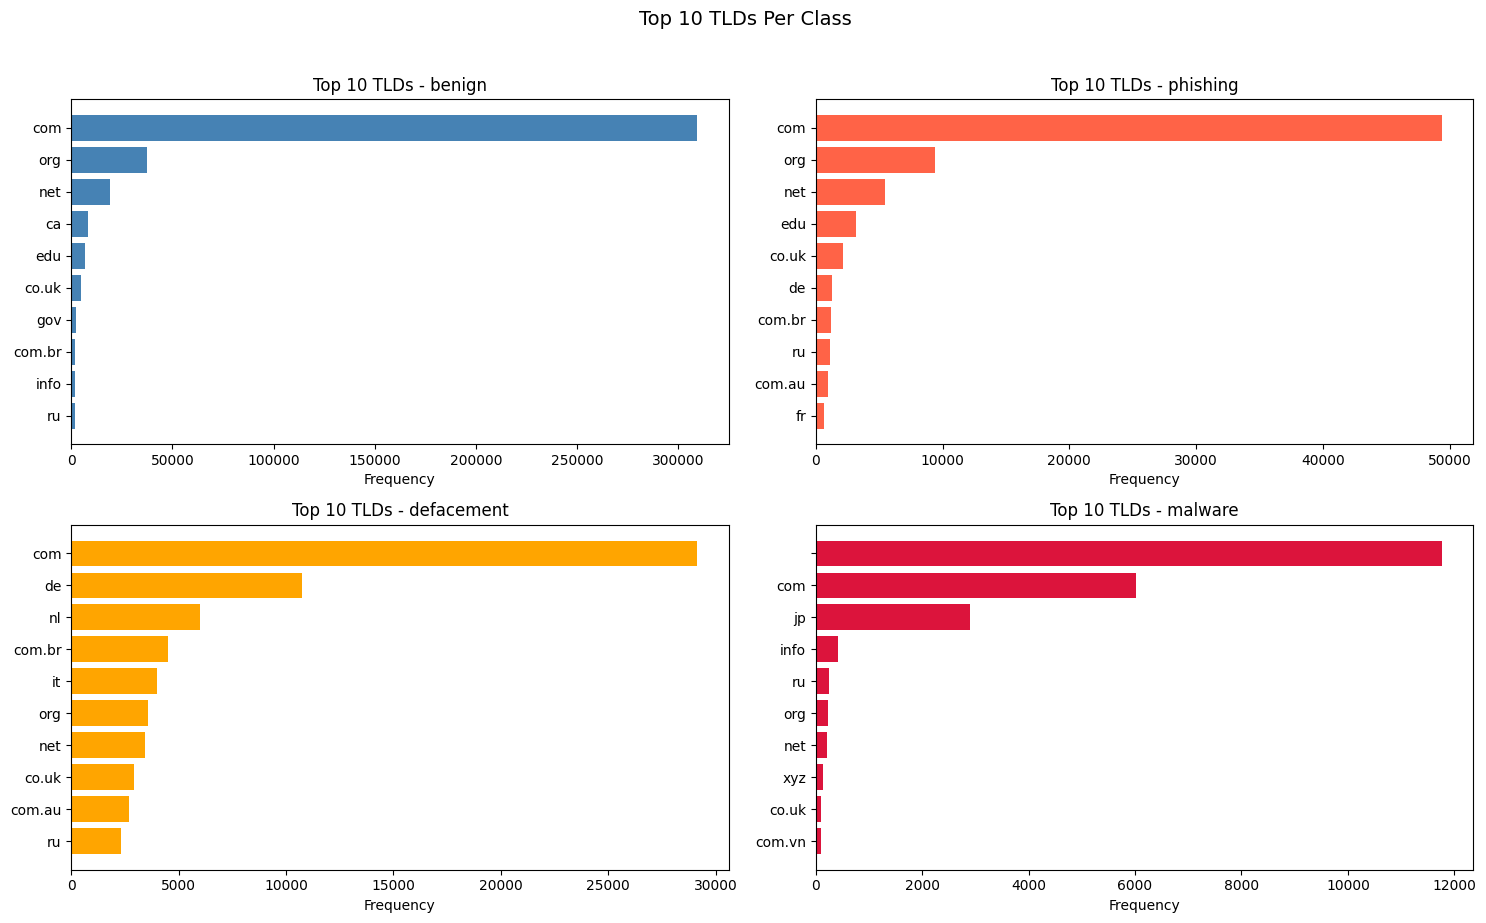

In [29]:
malicious_df['tld'] = malicious_df['url'].apply(lambda x: tldextract.extract(str(x)).suffix)

malware_blanks = malicious_df[(malicious_df['type'] == 'malware') & ((malicious_df['tld'].isna()) | (malicious_df['tld'] == ''))]
print(malware_blanks['url'].head(20).tolist())

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
colors = {'benign': 'steelblue', 'phishing': 'tomato', 'defacement': 'orange', 'malware': 'crimson'}

for ax, label in zip(axes.flatten(), ['benign', 'phishing', 'defacement', 'malware']):
    top_tld = malicious_df[malicious_df['type'] == label]['tld'].value_counts().head(10)
    ax.barh(top_tld.index[::-1], top_tld.values[::-1], color=colors[label])
    ax.set_title(f"Top 10 TLDs - {label}")
    ax.set_xlabel('Frequency')
plt.suptitle('Top 10 TLDs Per Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [30]:
malicious_df['tld'] = malicious_df['tld'].replace('',"IP_Address")
malicious_df['tld'] = malicious_df['tld'].fillna('IP_Address')

print(malicious_df['tld'].value_counts().head(10))

tld
com           393912
org            50768
net            28074
de             13472
IP_Address     12215
edu            10077
co.uk          10007
ca              9449
com.br          7629
nl              7067
Name: count, dtype: int64
tld
com           393912
org            50768
net            28074
de             13472
IP_Address     12215
edu            10077
co.uk          10007
ca              9449
com.br          7629
nl              7067
Name: count, dtype: int64


tld
com           393912
org            50768
net            28074
de             13472
IP_Address     12215
Name: count, dtype: int64
------------------------------


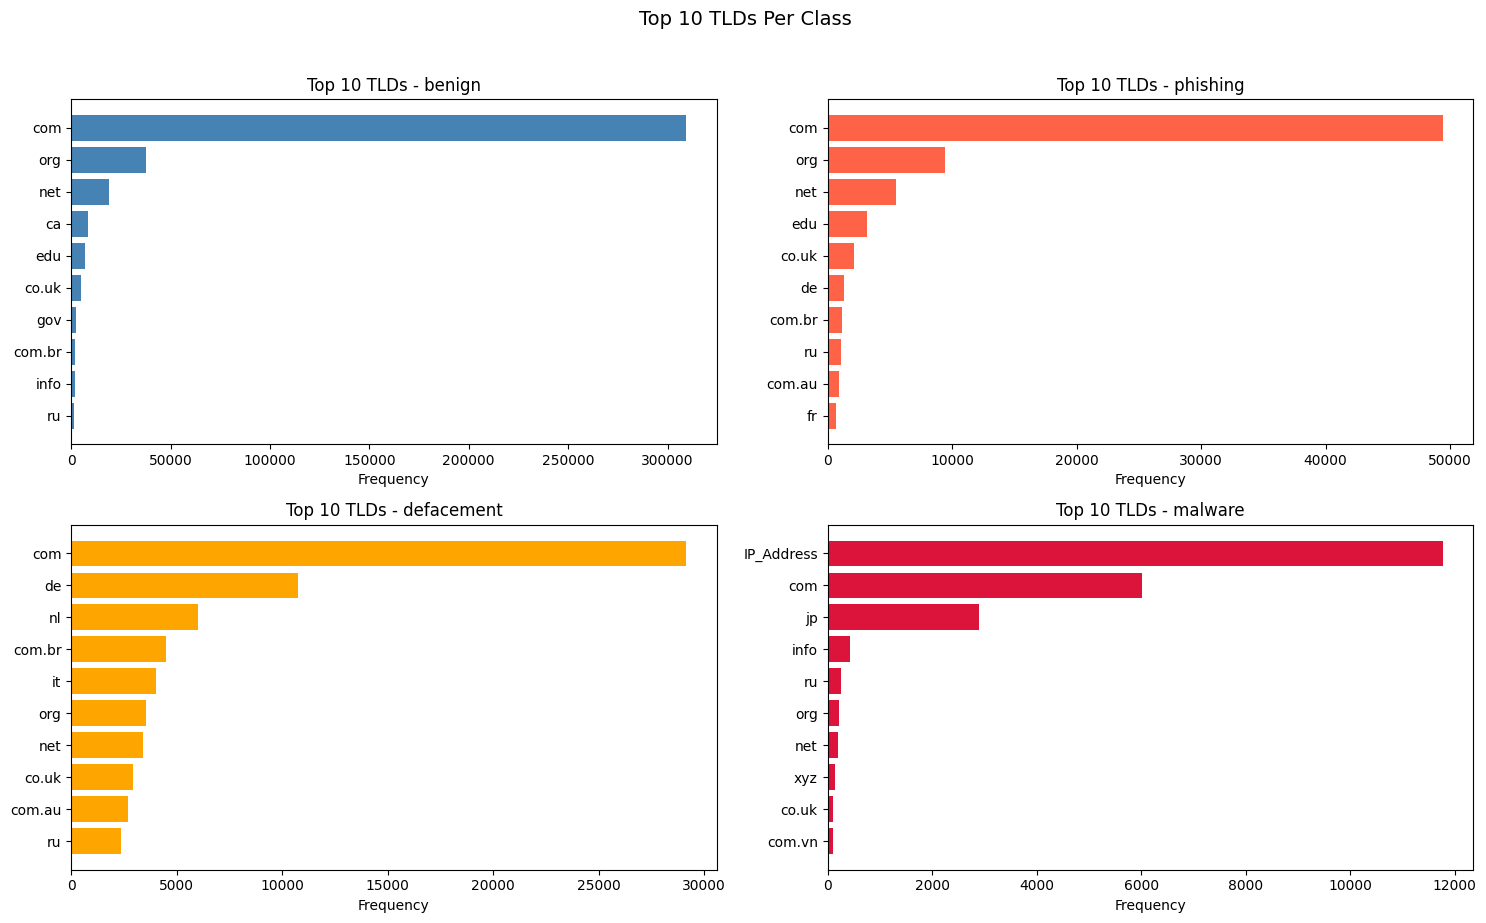

tld
com           393912
org            50768
net            28074
de             13472
IP_Address     12215
Name: count, dtype: int64
------------------------------


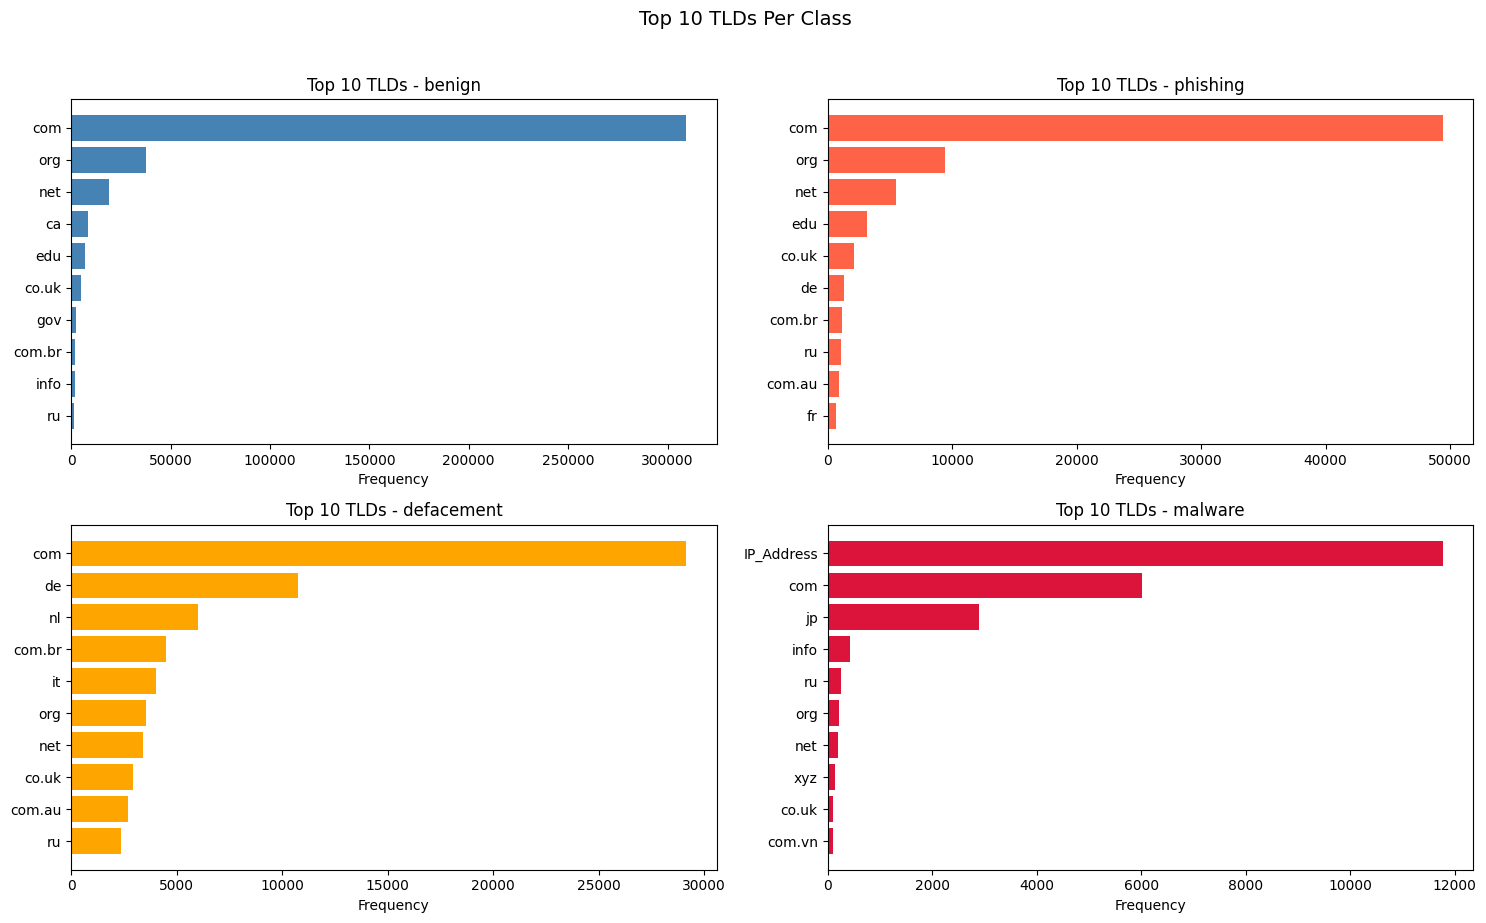

In [31]:
malicious_df['tld'] = malicious_df['tld'].astype(str).str.strip()
malicious_df.loc[malicious_df['tld'] == '', 'tld'] = 'IP_Address'
malicious_df.loc[malicious_df['tld'] == 'nan', 'tld'] = 'IP_Address'
print(malicious_df['tld'].value_counts().head(5))

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

for ax, label in zip(axes.flatten(), ['benign', 'phishing', 'defacement', 'malware']):
    top_tld = malicious_df[malicious_df['type'] == label]['tld'].value_counts().head(10)
    ax.barh(top_tld.index[::-1], top_tld.values[::-1], color=colors[label])
    ax.set_title(f"Top 10 TLDs - {label}")
    ax.set_xlabel('Frequency')
plt.suptitle('Top 10 TLDs Per Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

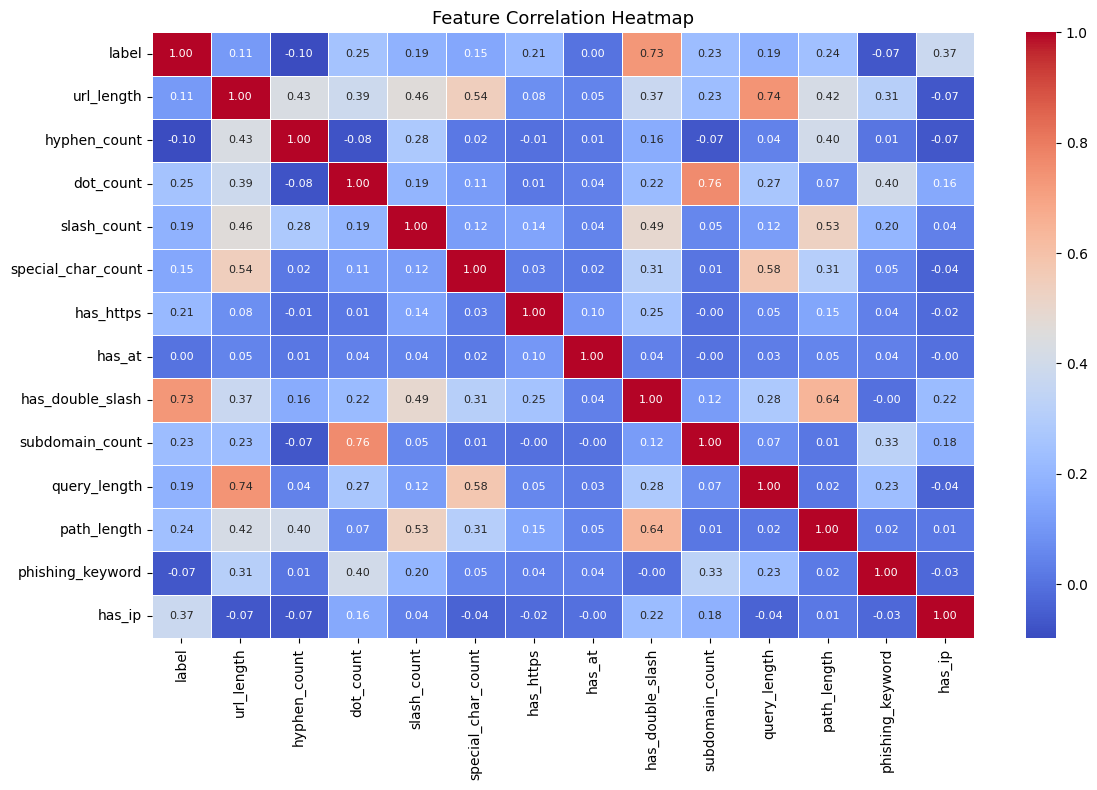

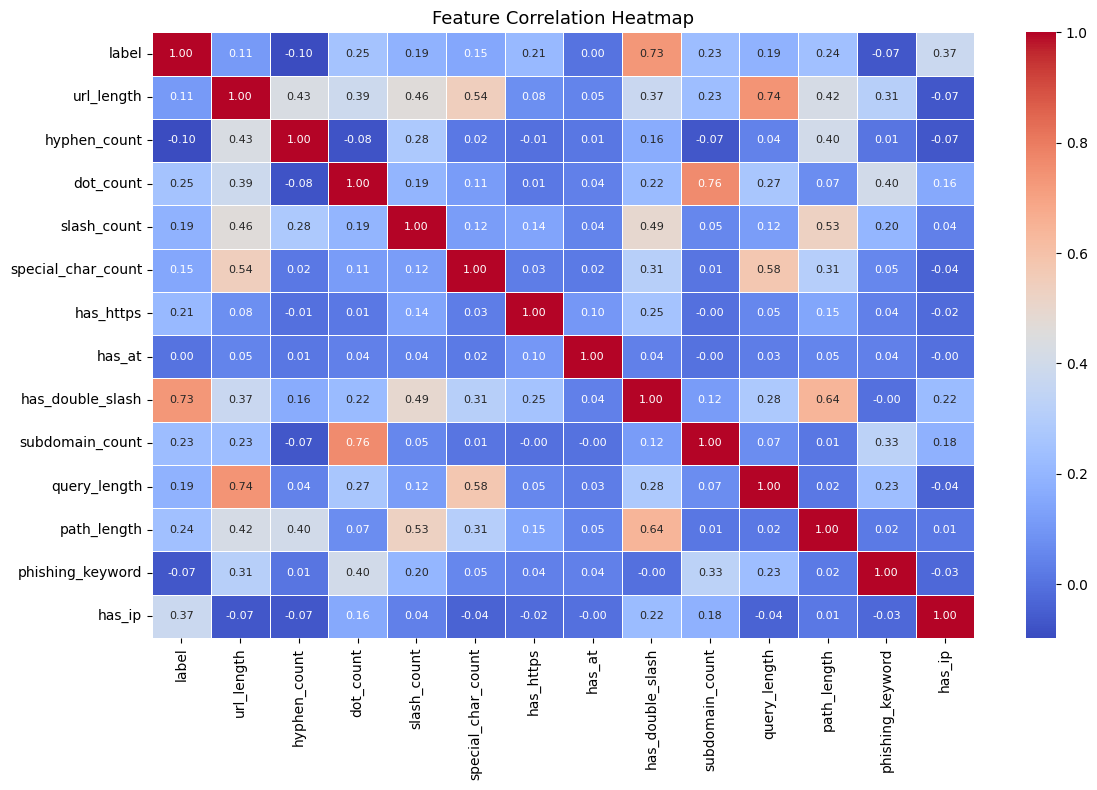

In [32]:
plt.figure(figsize=(12,8))
corr = malicious_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size':8})
plt.title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3835/3094966203.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(box_data, labels=['benign', 'phishing', 'defacement', 'malware'],


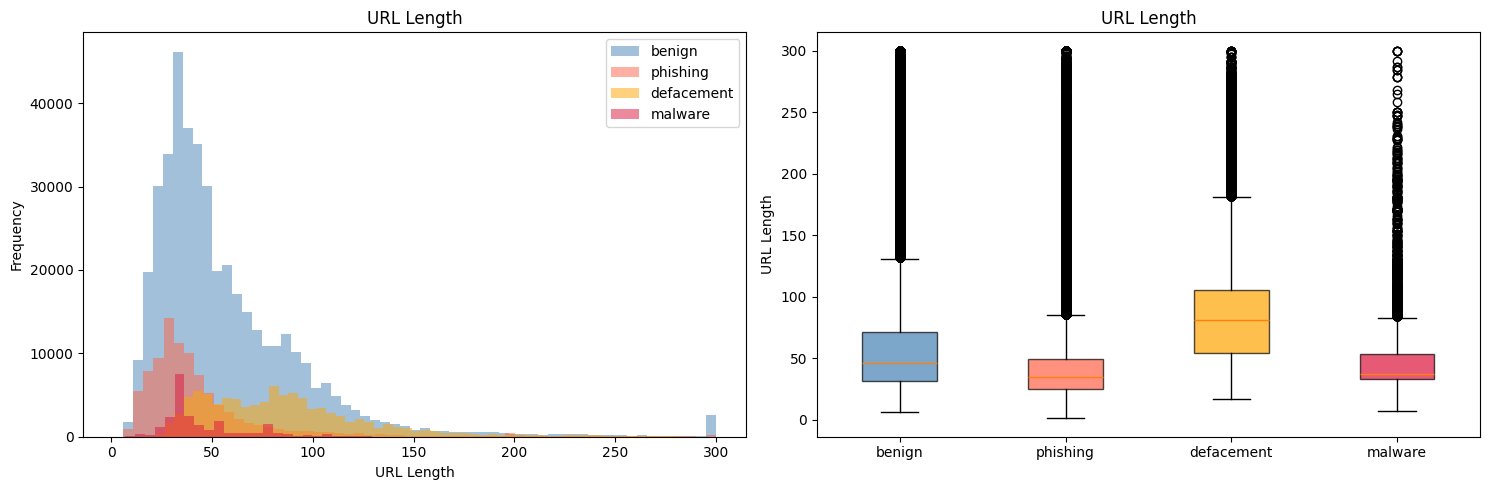

          count  mean   std   min   25%   50%    75%     max
label                                                       
0      428080.0  57.7  44.3   6.0  31.0  46.0   71.0  2175.0
1       94092.0  45.9  43.7   1.0  25.0  35.0   49.0  1779.0
2       95308.0  86.1  41.9  17.0  54.0  81.0  105.0   327.0
3       23645.0  46.6  25.0   7.0  33.0  37.0   53.0   378.0


/tmp/ipykernel_3835/3094966203.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(box_data, labels=['benign', 'phishing', 'defacement', 'malware'],


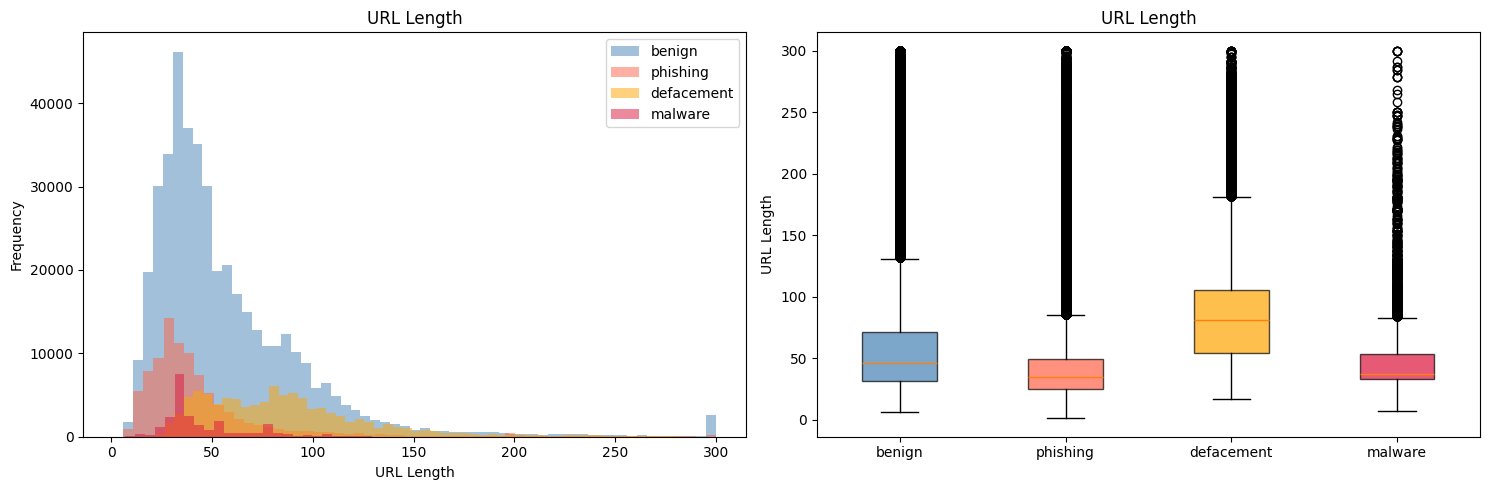

          count  mean   std   min   25%   50%    75%     max
label                                                       
0      428080.0  57.7  44.3   6.0  31.0  46.0   71.0  2175.0
1       94092.0  45.9  43.7   1.0  25.0  35.0   49.0  1779.0
2       95308.0  86.1  41.9  17.0  54.0  81.0  105.0   327.0
3       23645.0  46.6  25.0   7.0  33.0  37.0   53.0   378.0


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors = {0: 'steelblue', 1: 'tomato', 2: 'orange', 3: 'crimson'}

for name, lbl in label_map.items():
    data = malicious_df[malicious_df['label'] == lbl]['url_length'].clip(upper=300)
    axes[0].hist(data, bins=60, alpha=0.5, color=colors[lbl], label=name)

axes[0].set_xlabel("URL Length")
axes[0].set_ylabel('Frequency')
axes[0].set_title("URL Length")
axes[0].legend()

box_data = [
    malicious_df[malicious_df['label'] == l]['url_length'].clip(upper=300).values
    for l in label_map.values()
]
bp = axes[1].boxplot(box_data, labels=['benign', 'phishing', 'defacement', 'malware'],
                     patch_artist=True)

for box, color in zip(bp['boxes'], colors.values()):
    box.set_facecolor(color)
    box.set_alpha(0.7)

axes[1].set_title('URL Length')
axes[1].set_ylabel('URL Length')

plt.tight_layout()
plt.show()

print(malicious_df.groupby('label')['url_length'].describe().round(1))

/tmp/ipykernel_3835/3240154251.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=list(label_map.keys()), patch_artist=True)
/tmp/ipykernel_3835/3240154251.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=list(label_map.keys()), patch_artist=True)
/tmp/ipykernel_3835/3240154251.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=list(label_map.keys()), patch_artist=True)
/tmp/ipykernel_3835/3240154251.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matp

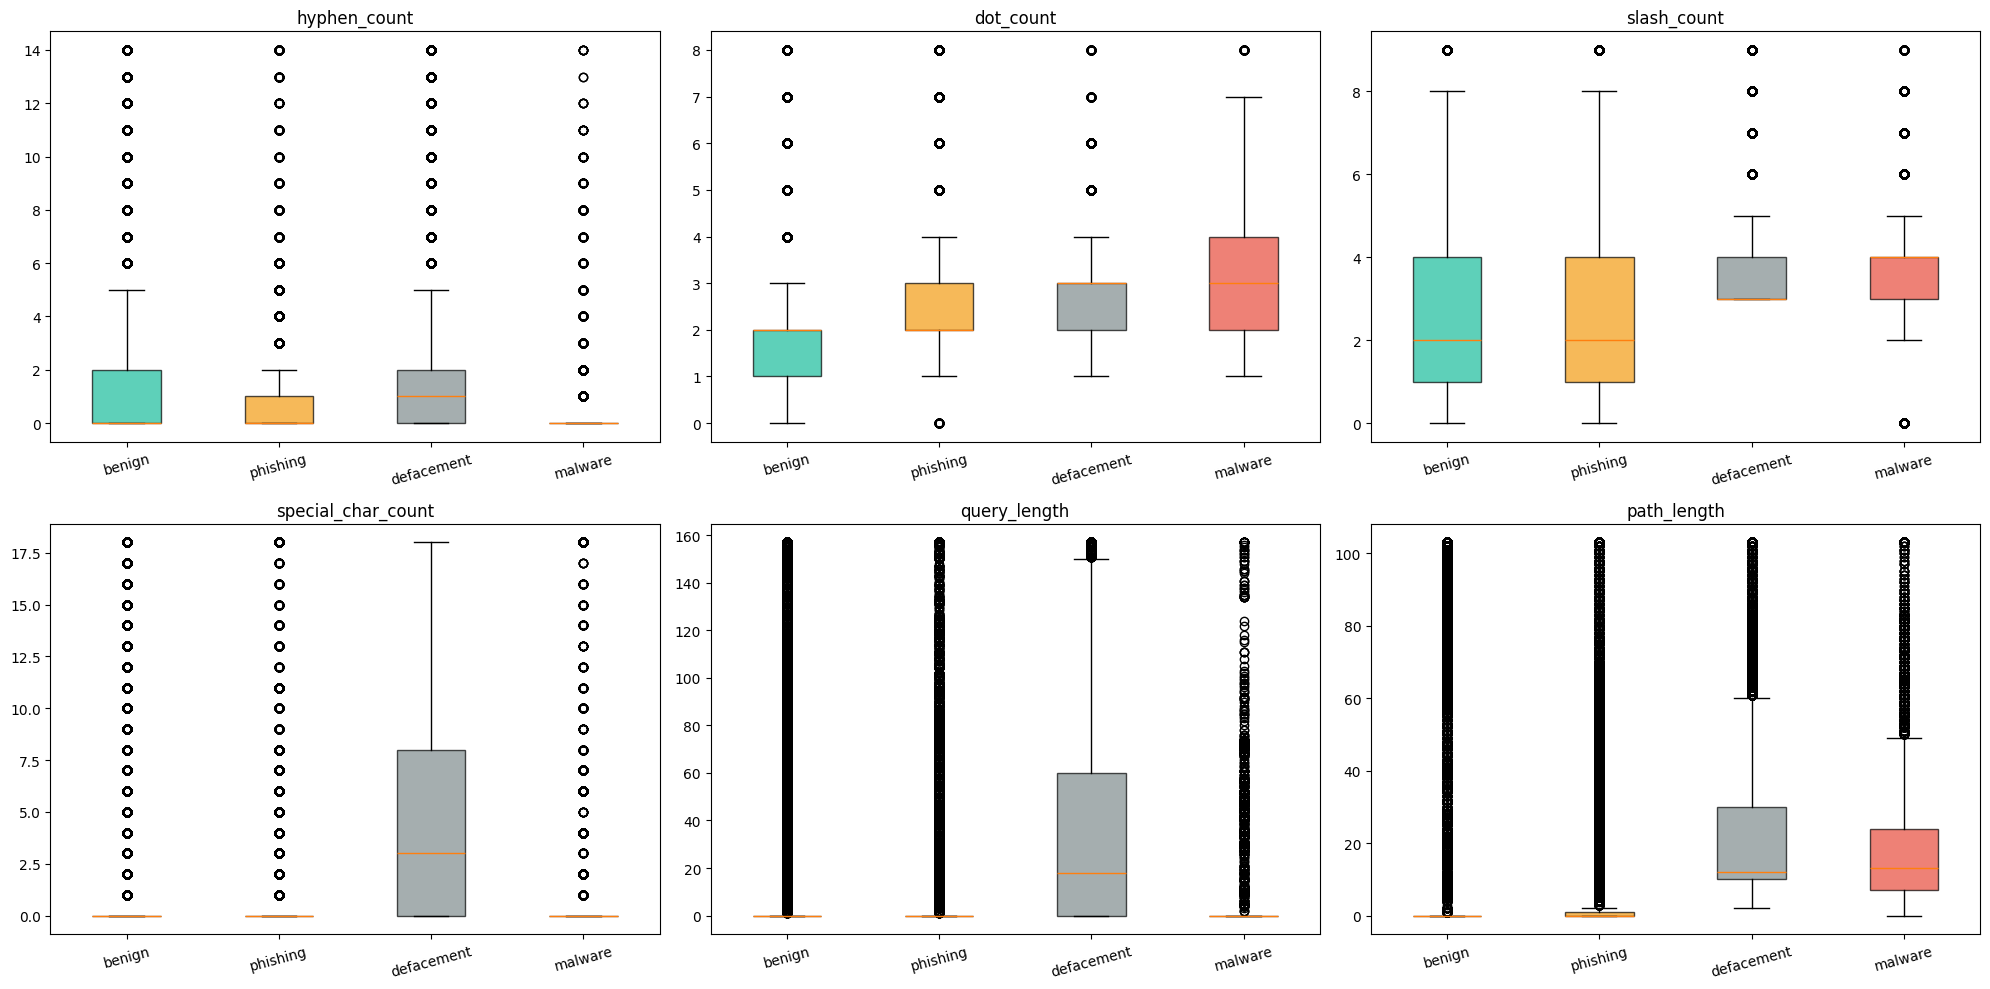

/tmp/ipykernel_3835/3240154251.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=list(label_map.keys()), patch_artist=True)
/tmp/ipykernel_3835/3240154251.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=list(label_map.keys()), patch_artist=True)
/tmp/ipykernel_3835/3240154251.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=list(label_map.keys()), patch_artist=True)
/tmp/ipykernel_3835/3240154251.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matp

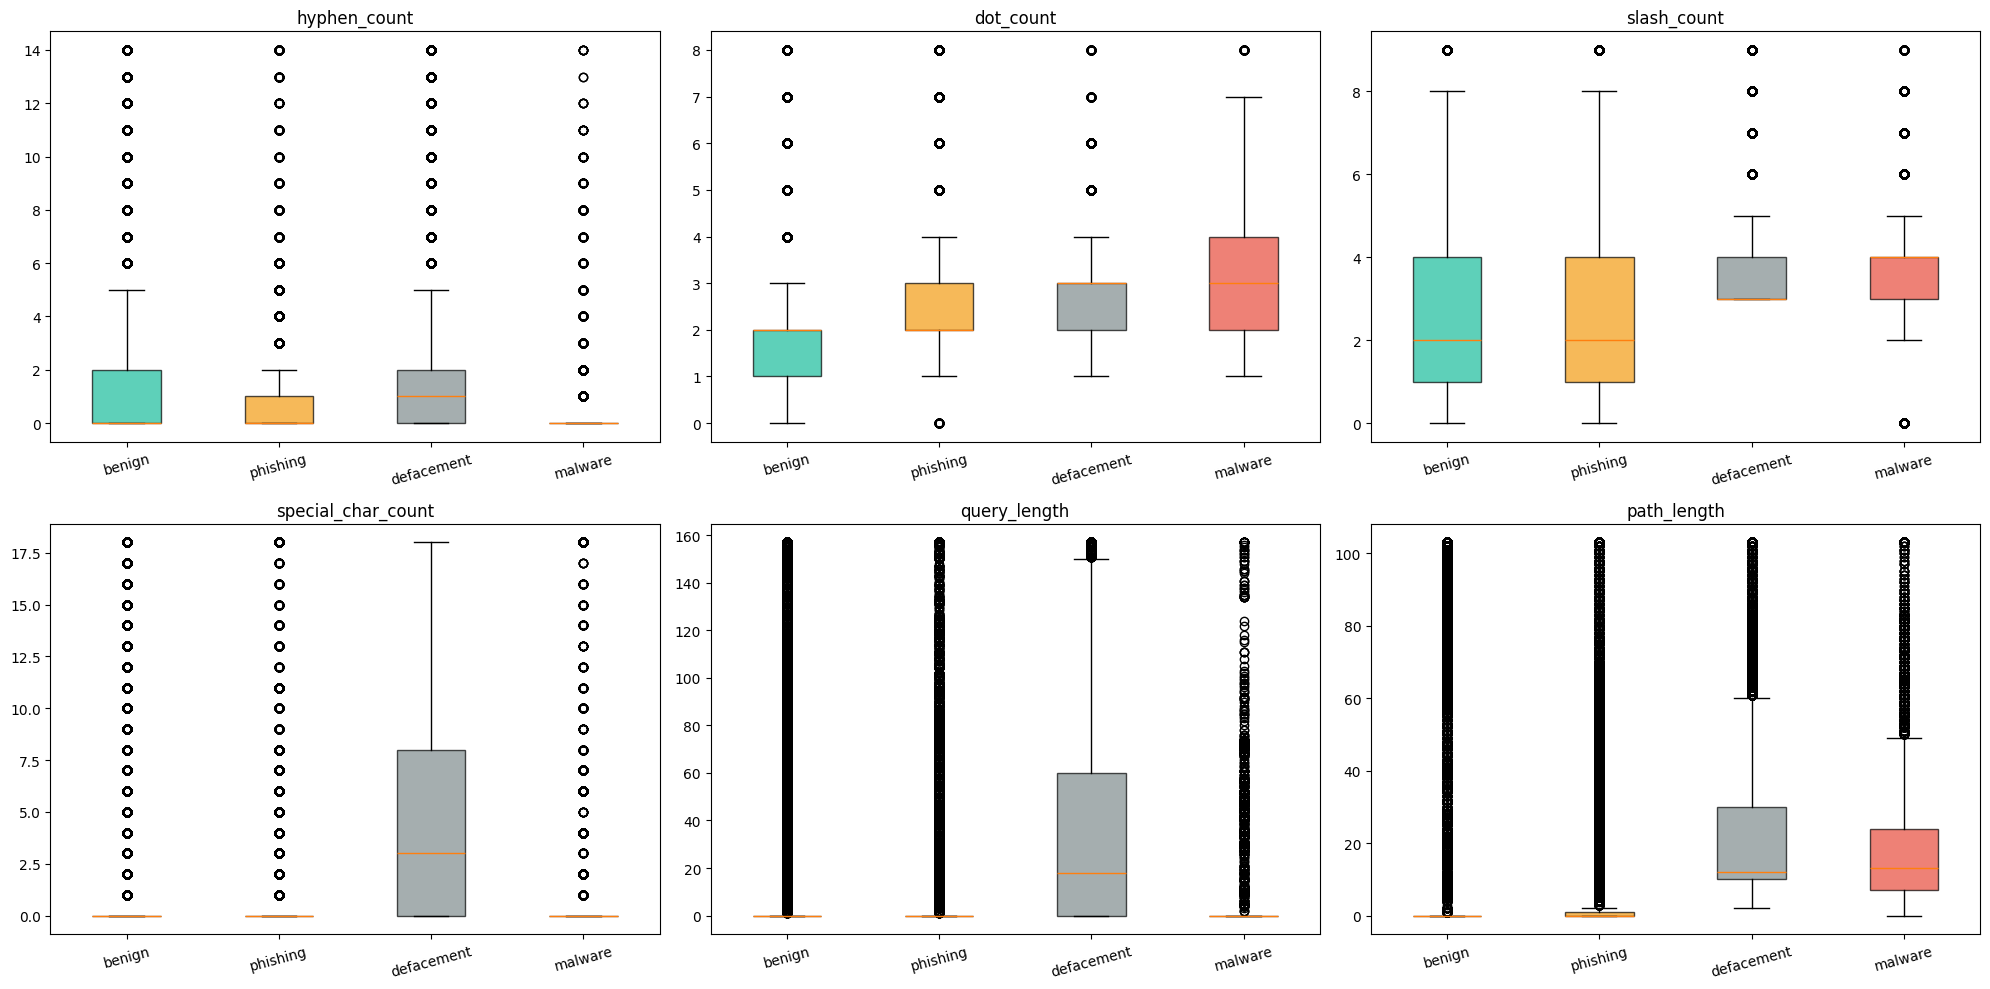

In [34]:
count_features = ['hyphen_count', 'dot_count', 'slash_count',
                  'special_char_count', 'query_length', 'path_length']

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for ax, feat in zip(axes, count_features):
    cap = malicious_df[feat].quantile(0.99)
    box_data = [
        malicious_df[malicious_df['label'] == l][feat].clip(upper=cap)
        for l in label_map.values()
    ]
    bp = ax.boxplot(box_data, labels=list(label_map.keys()), patch_artist=True)
    for box, color in zip(bp['boxes'], bar_colors):
        box.set_facecolor(color)
        box.set_alpha(0.7)

    ax.set_title(feat)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

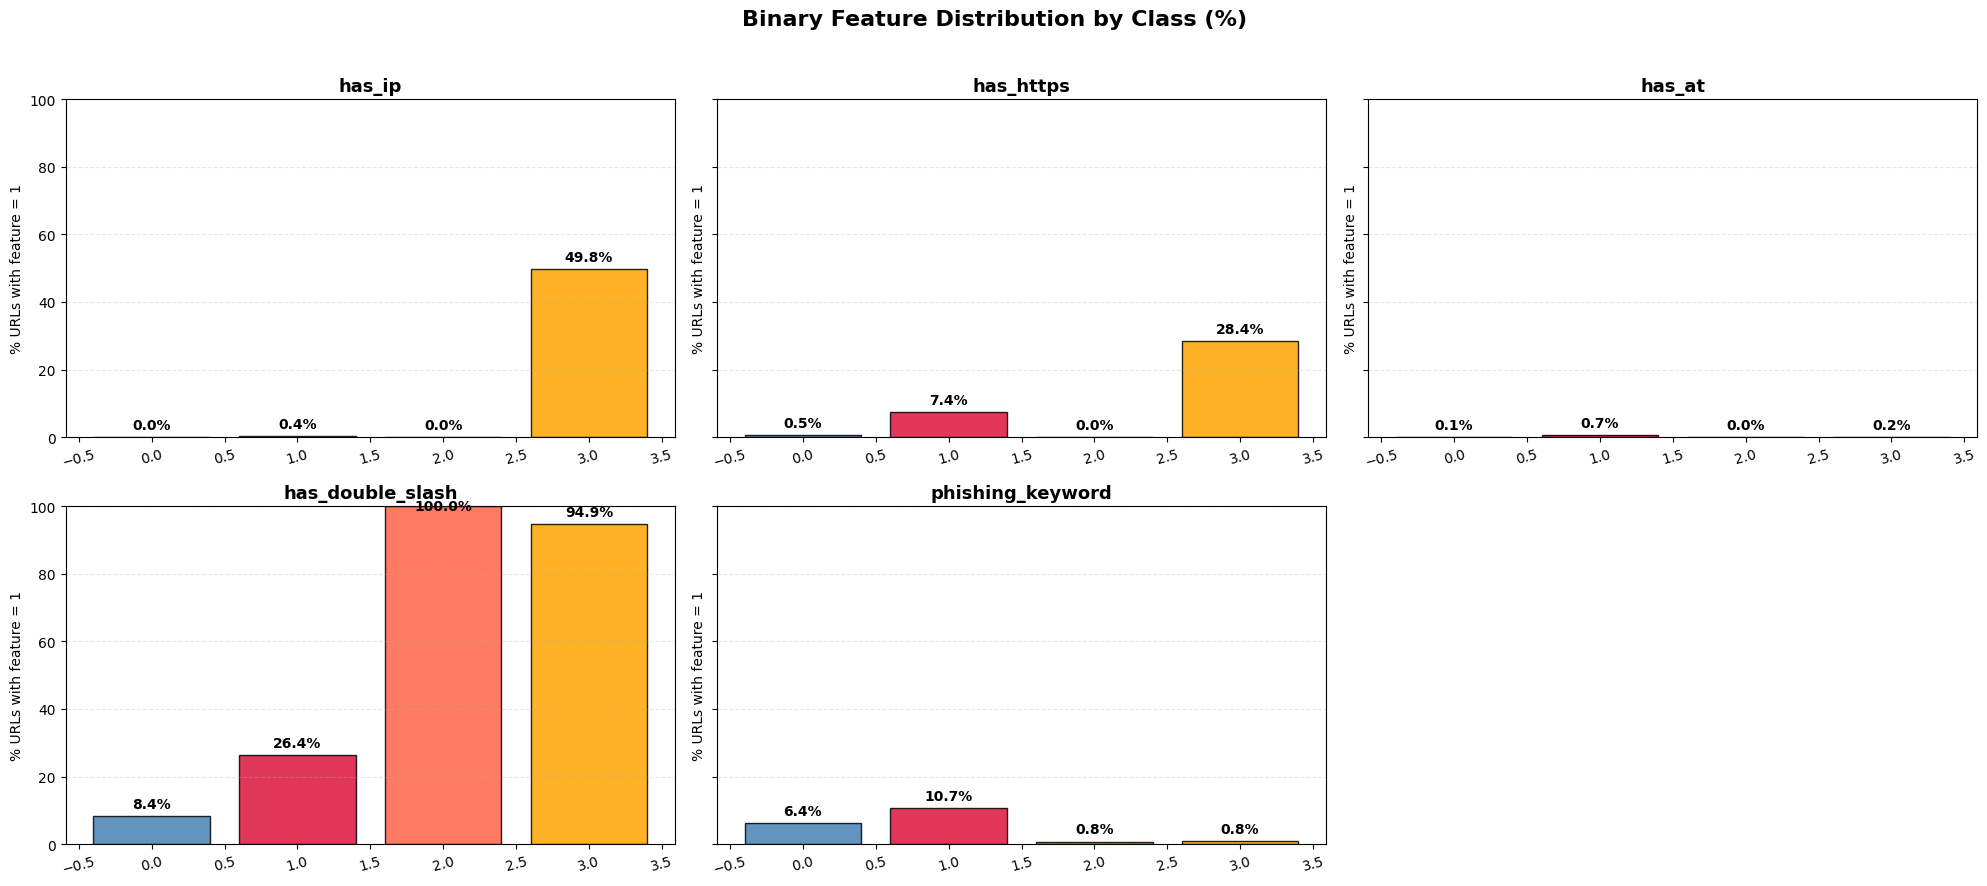

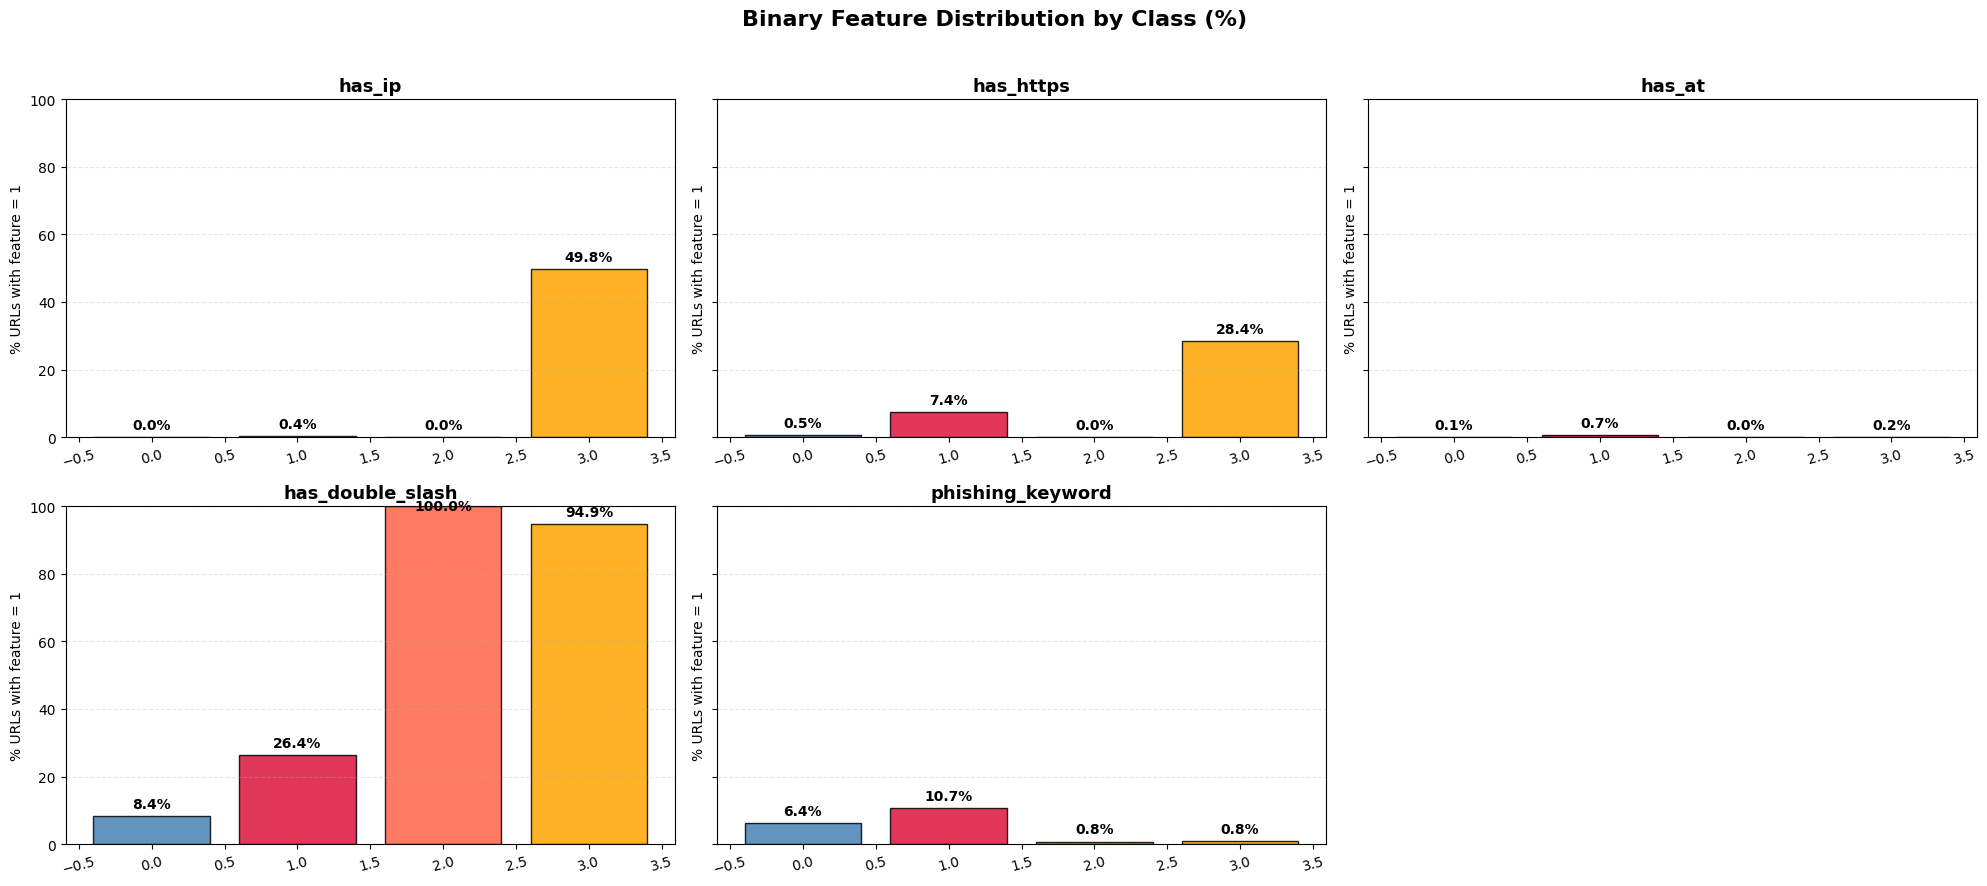

In [35]:
# Binary features
binary_features = ['has_ip','has_https','has_at','has_double_slash','phishing_keyword'
]
# Colors for each class
colors = ['steelblue', 'tomato', 'orange', 'crimson']
# Create subplots (share y-axis)
fig, axes = plt.subplots(
    2, 3,
    figsize=(20, 9),
    sharey=True
)
axes = axes.flatten()
for ax, col in zip(axes, binary_features):
    # Percentage of URLs having feature = 1
    pct = malicious_df.groupby('type')[col].mean() * 100
    pct.index = pct.index.map(label_map)
    # Bar plot
    bars = ax.bar(
        pct.index,
        pct.values,color=colors,edgecolor='black',alpha=0.85
    )
    # Title
    ax.set_title(col, fontsize=13, fontweight='bold')
    # Labels
    ax.set_ylabel('% URLs with feature = 1')
    ax.set_ylim(0, 100)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.tick_params(axis='x', rotation=15)
    # Percentage labels
    for bar, val in zip(bars, pct.values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            min(val + 1.5, 98),
            f'{val:.1f}%',
            ha='center',va='bottom',fontsize=10,fontweight='bold'
        )
axes[-1].axis('off')
plt.suptitle(
    'Binary Feature Distribution by Class (%)',
    fontsize=16,
    fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [36]:
malicious_df.head()

,url,type,label,url_length,hyphen_count,dot_count,slash_count,special_char_count,has_https,has_at,has_double_slash,subdomain_count,query_length,path_length,phishing_keyword,has_ip,tld
0,br-icloud.com.br,phishing,1,16,1,2,0,0,False,False,False,2,0.0,0.0,False,0,com.br
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,0,2,2,0,False,False,False,1,0.0,0.0,False,0,com
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,0,2,3,0,False,False,False,1,0.0,0.0,False,0,org
3,http://www.garage-pirenne.be/index.php?option=...,defacement,2,88,1,3,3,8,False,False,True,2,49.0,10.0,False,0,be
4,http://adventure-nicaragua.net/index.php?optio...,defacement,2,235,1,2,3,6,False,False,True,1,194.0,10.0,False,0,net


,url,type,label,url_length,hyphen_count,dot_count,slash_count,special_char_count,has_https,has_at,has_double_slash,subdomain_count,query_length,path_length,phishing_keyword,has_ip,tld
0,br-icloud.com.br,phishing,1,16,1,2,0,0,False,False,False,2,0.0,0.0,False,0,com.br
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,0,2,2,0,False,False,False,1,0.0,0.0,False,0,com
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,0,2,3,0,False,False,False,1,0.0,0.0,False,0,org
3,http://www.garage-pirenne.be/index.php?option=...,defacement,2,88,1,3,3,8,False,False,True,2,49.0,10.0,False,0,be
4,http://adventure-nicaragua.net/index.php?optio...,defacement,2,235,1,2,3,6,False,False,True,1,194.0,10.0,False,0,net
